In [1]:
import warnings
warnings.filterwarnings('ignore')
import sys
import os
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), "..", "utils")))
from analysis_utils import (
    volcano_plot_br,
    plot_spatial_clusters_per_sample,
    plot_dotplot_by_treatment,
    plot_relative_cluster_composition,
    score_and_plot_modules, 
    volcano_plot_region_within_group
)
import scanpy as sc
import numpy as np

import scanpy as sc
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

pig_genes  = [
    "Apoe", "Arpc1b", "Axl", "B2m", "C1qa", "C1qb", "C1qc", "C4b",
    "Cd63", "Cd9", "Clu", "Csf1r", "Cst3", "Ctsa", "Ctsb", "Ctsd",
    "Ctsh", "Ctsl", "Ctss", "Ctsz", "Cx3cr1", "Cyba", "Fcer1g", "Fcgr3",
    "Fcrls", "Gfap", "Gns", "Grn", "Gusb", "H2-D1", "H2-K1", "Hexa",
    "Hexb", "Igfbp5", "Itgb5", "Itm2b", "Laptm5", "Lgals3bp", "Lgmn", "Ly86",
    "Lyz2", "Man2b1", "Mpeg1", "Npc2", "Olfml3", "Plek", "Prdx6",
    "S100a6", "Serpina3n", "Trem2", "Tyrobp", "Vsir"
]
olig_genes = [
    "Plp1", "Mbp", "Mobp", "Cnp", "Cldn11", "Mal", "Apod", "Trf", "Fth1", "Plekhb1", "Ppp1r14a", "Ttyh2", "Fa2h", "Aspa"
]
modules = {
    "PIG": pig_genes,
    "OLIG": olig_genes
}




In [2]:
ad = sc.read_h5ad('../data/ST_BRICHOS_region_subcluster.h5ad')

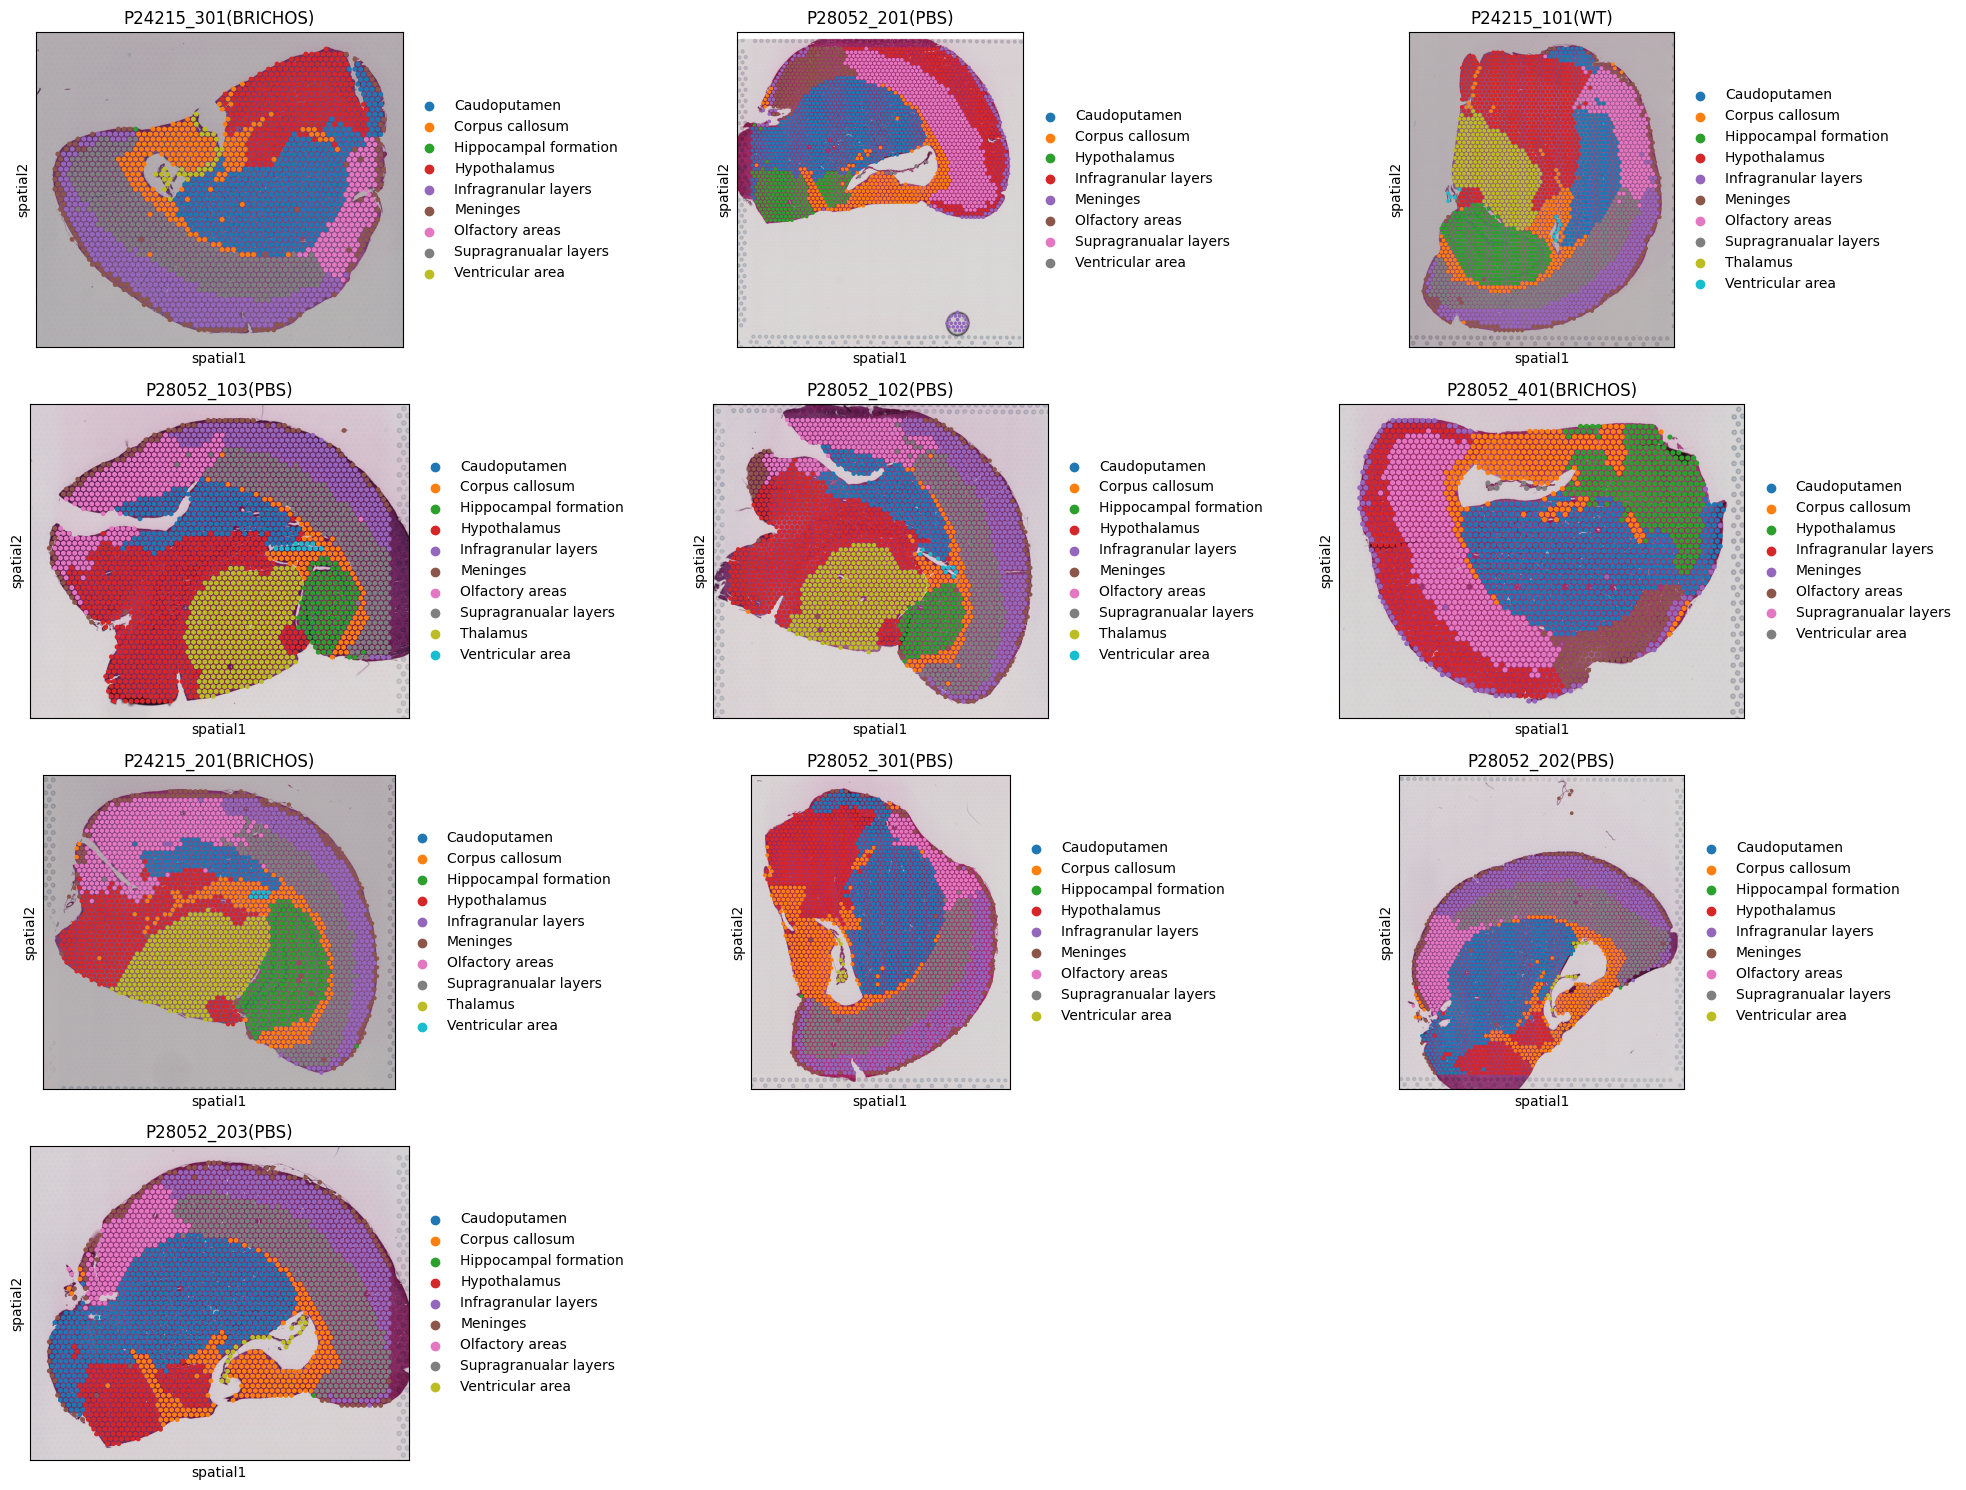

In [4]:
plot_spatial_clusters_per_sample(ad, color = 're_annotation_regions', figsize=(20,15))

In [5]:
pig_genes = [
    "Apoe", "Clu", "Ctsd", "C1qa", "C1qb", "C1qc", "C4b", "Tyrobp", "Trem2",
    "Cst7", "Fcer1g", "Axl", "Lpl", "Csf1", "Csf1r", "Cst3", "Ctsb",
    "Gpnmb", "Hexb", "Lyz2", "Slc2a5", "Serpina3n", "Lgals3", "Itgax", "C3"
]

In [4]:
sc.tl.score_genes(ad, gene_list=pig_genes, score_name="PIG_score")

In [9]:
ad_sub = ad[ad.obs.treatment == 'PBS']

In [10]:
region_scores = ad_sub.obs.groupby("re_annotation_regions")["PIG_score"].mean().sort_values(ascending=False)

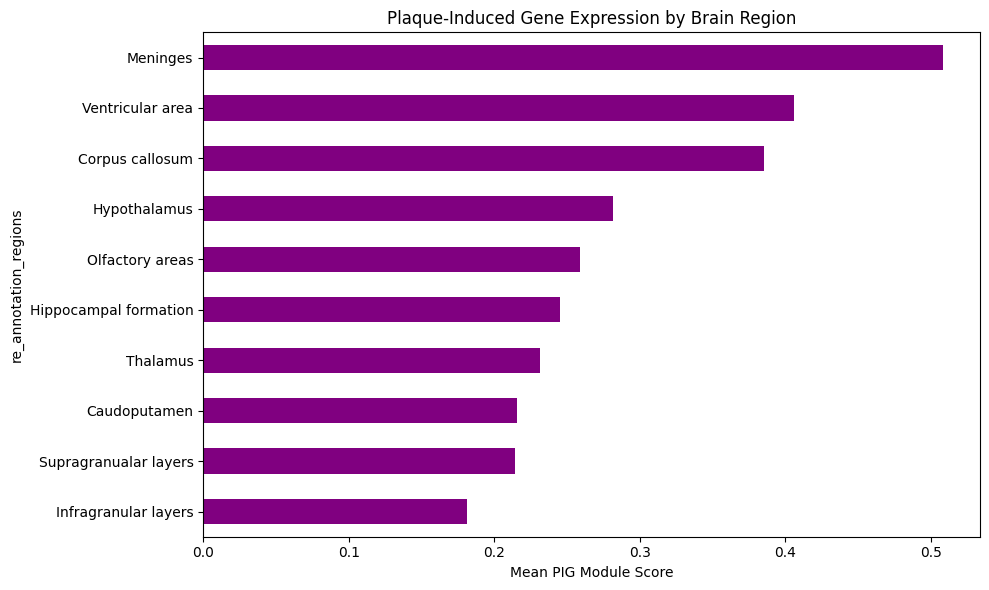

In [11]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
region_scores.plot(kind="barh", color="purple")
plt.xlabel("Mean PIG Module Score")
plt.title("Plaque-Induced Gene Expression by Brain Region")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [16]:
group = "PBS"  # or "PBS"
ad_sub = ad[ad.obs["treatment"] == group].copy()

In [17]:
sc.tl.rank_genes_groups(
    ad_sub,
    groupby="re_annotation_regions",
    method="t-test_overestim_var"
)

In [18]:
region_de_df = sc.get.rank_genes_groups_df(ad_sub, group=None)  # returns all groups

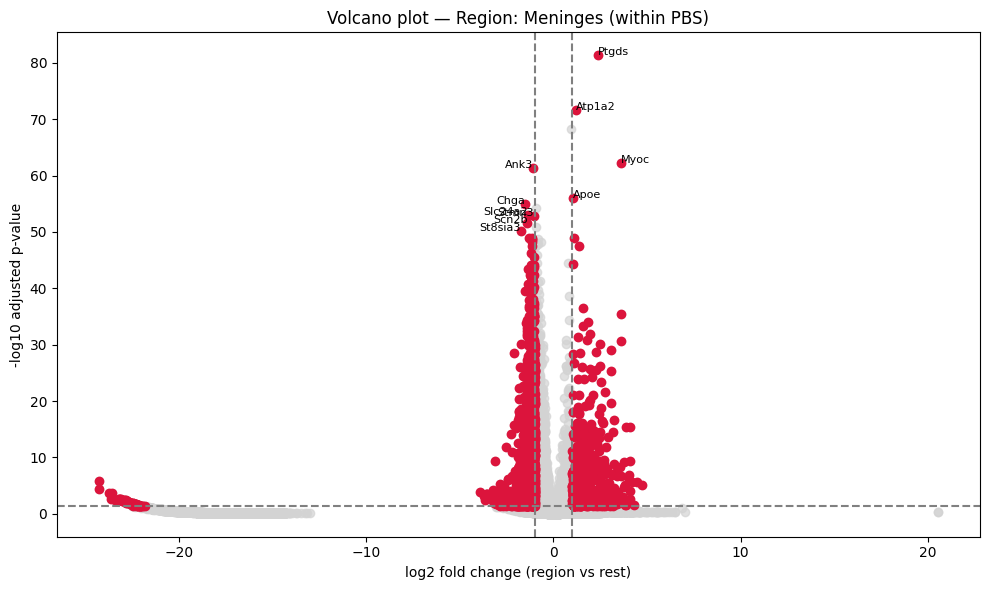

In [19]:
volcano_plot_region_within_group(ad_sub, region="Meninges")

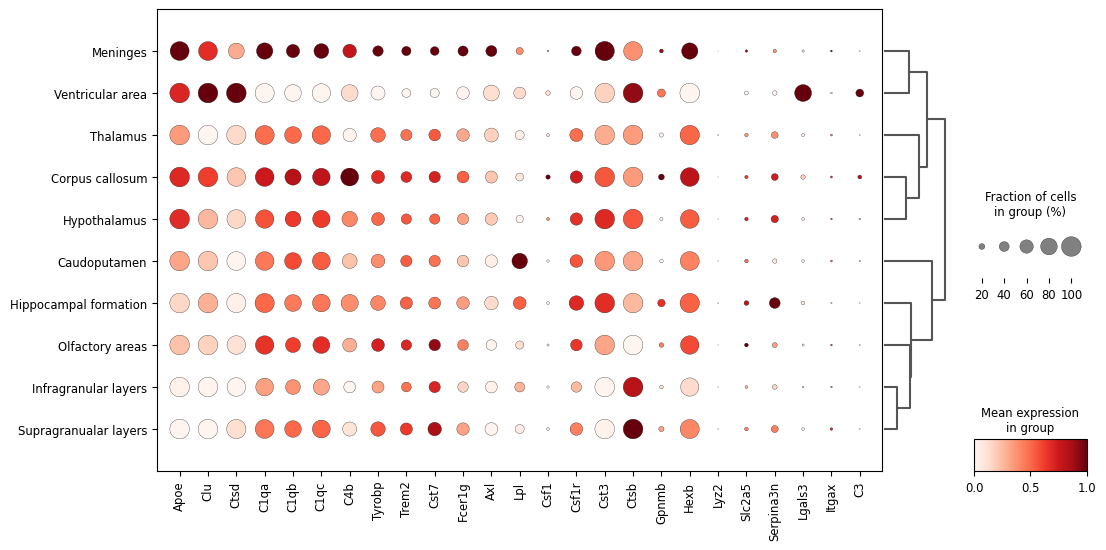

In [22]:
# Filter PBS samples with region annotations
ad_pbs = ad[(ad.obs["treatment"] == "PBS") & (ad.obs["re_annotation_regions"].notna())].copy()

# Plot dotplot of PIG genes across regions
sc.pl.dotplot(
    ad_pbs,
    var_names=pig_genes,
    groupby="re_annotation_regions",
    standard_scale='var',  # optional: normalize each gene across groups
    dendrogram=True,
    figsize=(12, 6),
    show=True
)

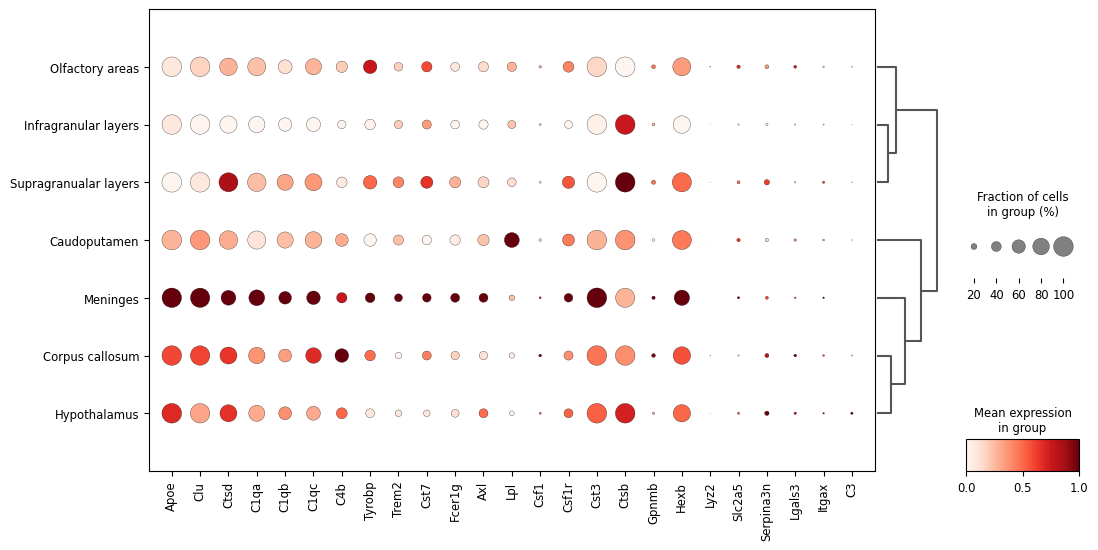

In [24]:
# Filter PBS samples with region annotations
ad_pbs = ad[(ad.obs["treatment"] == "BRICHOS") & (ad.obs["region_annotation"].notna())].copy()

# Plot dotplot of PIG genes across regions
sc.pl.dotplot(
    ad_pbs,
    var_names=pig_genes,
    groupby="re_annotation_regions",
    standard_scale='var',  # optional: normalize each gene across groups
    dendrogram=True,
    figsize=(12, 6),
    show=True
)

✅ Scored PIG module with 52 genes
✅ Scored OLIG module with 14 genes


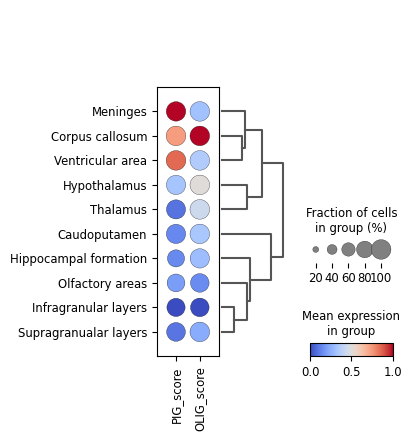

In [25]:
score_and_plot_modules(ad, modules, groupby="re_annotation_regions")

✅ Scored PIG module with 25 genes
✅ Scored OLIG module with 14 genes


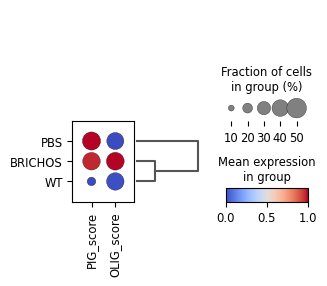

In [17]:
modules = {
    "PIG": pig_genes,
    "OLIG": olig_genes
}
score_and_plot_modules(ad, modules, groupby="treatment")

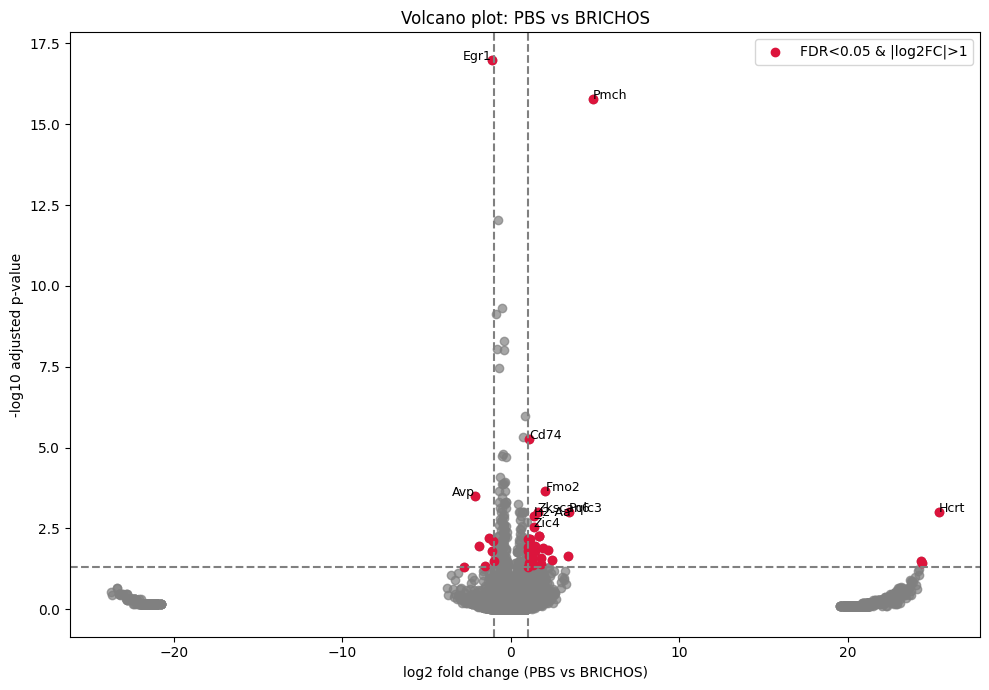

In [28]:
ad_sub = ad[ad.obs.re_annotation_regions == 'Meninges']
volcano_plot_br(ad_sub, groupby='treatment',
    group1='PBS',
    group2='BRICHOS')

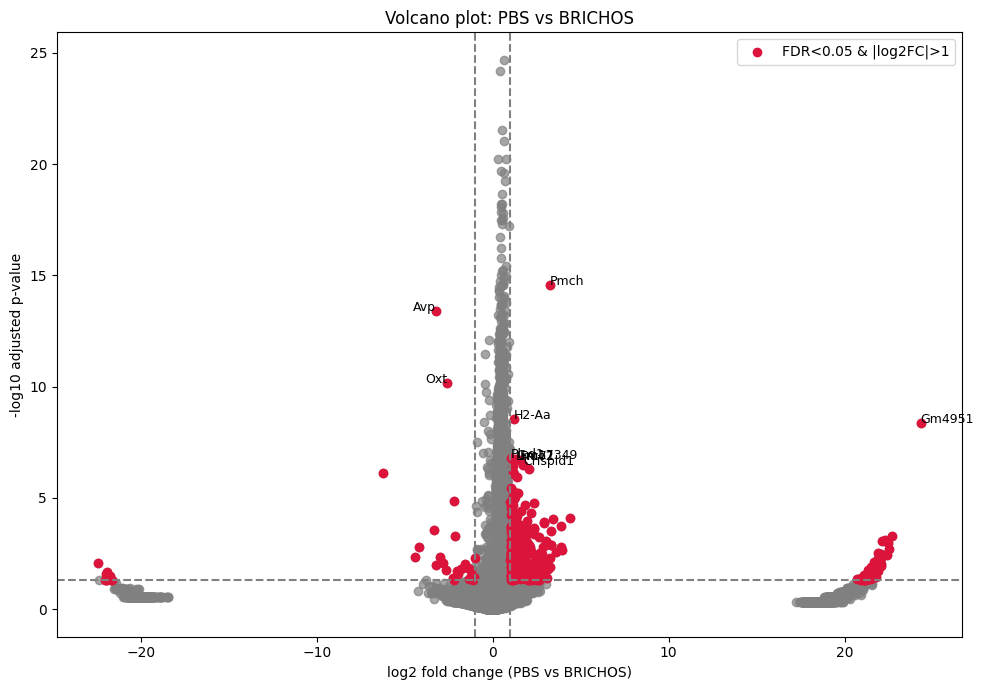

In [30]:
ad_sub = ad[ad.obs.re_annotation_regions == 'Corpus callosum']
volcano_plot_br(ad_sub, groupby='treatment',
    group1='PBS',
    group2='BRICHOS')

In [39]:

# group mean PIG scores
region_summary = (
    ad.obs.groupby(["re_annotation_regions", "treatment"])["PIG_score"]
    .mean()
    .reset_index()
)

print(region_summary.head())
pivot_tbl = region_summary.pivot(index="re_annotation_regions", columns="treatment", values="PIG_score")
pivot_tbl["PBS_vs_WT"] = pivot_tbl["PBS"] - pivot_tbl["WT"]
pivot_tbl["BRICHOS_vs_PBS"] = pivot_tbl["BRICHOS"] - pivot_tbl["PBS"]
pivot_tbl = pivot_tbl.sort_values("PBS_vs_WT", ascending=False)
print(pivot_tbl)

  re_annotation_regions treatment  PIG_score
0          Caudoputamen   BRICHOS   0.199974
1          Caudoputamen       PBS   0.215898
2          Caudoputamen        WT   0.069935
3       Corpus callosum   BRICHOS   0.435031
4       Corpus callosum       PBS   0.385445
treatment               BRICHOS       PBS        WT  PBS_vs_WT  BRICHOS_vs_PBS
re_annotation_regions                                                         
Meninges               0.473965  0.508435  0.301572   0.206863       -0.034470
Olfactory areas        0.214734  0.258947  0.052708   0.206240       -0.044213
Supragranualar layers  0.178964  0.214428  0.021512   0.192916       -0.035464
Infragranular layers   0.154965  0.181562  0.018784   0.162778       -0.026597
Thalamus               0.196660  0.231668  0.074256   0.157412       -0.035009
Caudoputamen           0.199974  0.215898  0.069935   0.145964       -0.015924
Hypothalamus           0.283168  0.281806  0.137200   0.144606        0.001362
Hippocampal formati

In [40]:
region_summary

,re_annotation_regions,treatment,PIG_score
0,Caudoputamen,BRICHOS,0.199974
1,Caudoputamen,PBS,0.215898
2,Caudoputamen,WT,0.069935
3,Corpus callosum,BRICHOS,0.435031
4,Corpus callosum,PBS,0.385445
5,Corpus callosum,WT,0.267765
6,Hippocampal formation,BRICHOS,0.248514
7,Hippocampal formation,PBS,0.245319
8,Hippocampal formation,WT,0.120588
9,Hypothalamus,BRICHOS,0.283168


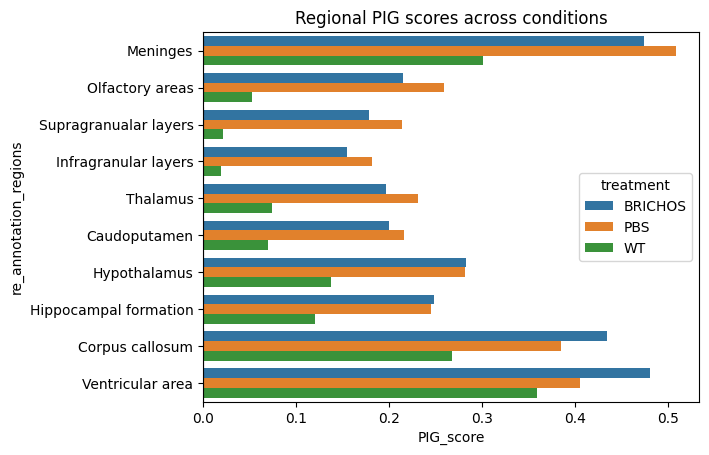

In [41]:
sns.barplot(
    data=region_summary,
    x="PIG_score", y="re_annotation_regions", hue="treatment",
    order=pivot_tbl.index
)
plt.axvline(0, color="k", linestyle="--")
plt.title("Regional PIG scores across conditions")
plt.show()

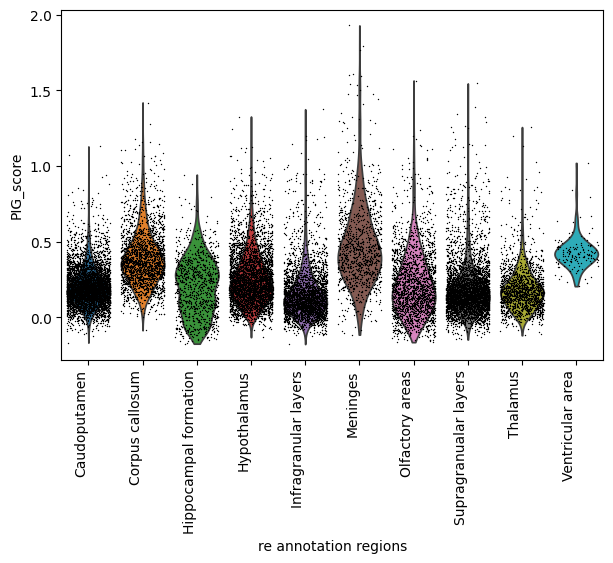

In [52]:
import matplotlib.pyplot as plt

ax = sc.pl.violin(
    ad,
    keys="PIG_score",
    groupby="re_annotation_regions",
    stripplot=True,
    jitter=0.4,
    show=False  # prevent auto-show so you can modify
)

plt.xticks(rotation=90, ha="right")  # rotate labels
plt.tight_layout()
plt.show()

In [35]:
import pandas as pd

# group mean PIG scores
region_summary = (
    ad.obs.groupby(["re_annotation_regions", "treatment"])["OLIG_score"]
    .mean()
    .reset_index()
)

print(region_summary.head())
pivot_tbl = region_summary.pivot(index="re_annotation_regions", columns="treatment", values="OLIG_score")
pivot_tbl["PBS_vs_WT"] = pivot_tbl["PBS"] - pivot_tbl["WT"]
pivot_tbl["BRICHOS_vs_PBS"] = pivot_tbl["BRICHOS"] - pivot_tbl["PBS"]
pivot_tbl = pivot_tbl.sort_values("PBS_vs_WT", ascending=False)
print(pivot_tbl)

  re_annotation_regions treatment  OLIG_score
0          Caudoputamen   BRICHOS    0.865069
1          Caudoputamen       PBS    0.878367
2          Caudoputamen        WT    0.766509
3       Corpus callosum   BRICHOS    1.997360
4       Corpus callosum       PBS    1.882036
treatment               BRICHOS       PBS        WT  PBS_vs_WT  BRICHOS_vs_PBS
re_annotation_regions                                                         
Ventricular area       0.973721  0.888006  0.753275   0.134731        0.085715
Thalamus               1.092754  1.060720  0.941961   0.118758        0.032034
Caudoputamen           0.865069  0.878367  0.766509   0.111859       -0.013298
Infragranular layers   0.338485  0.356246  0.295428   0.060818       -0.017761
Hypothalamus           1.205211  1.145244  1.099002   0.046241        0.059968
Supragranualar layers  0.705420  0.745095  0.714014   0.031081       -0.039674
Hippocampal formation  0.875475  0.767243  0.795572  -0.028329        0.108233
Olfactory are

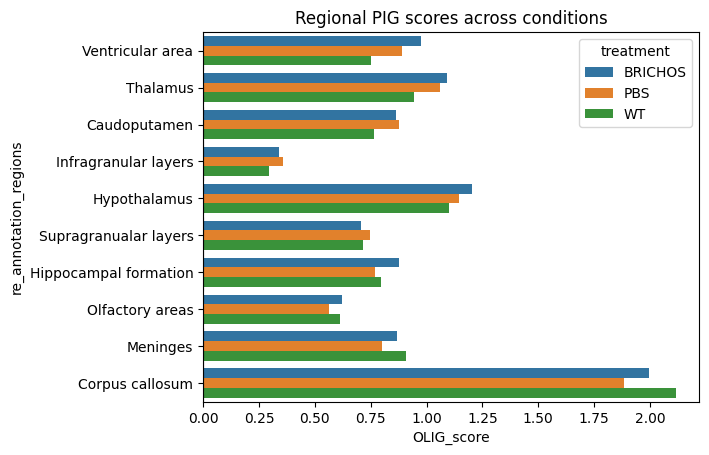

In [36]:
sns.barplot(
    data=region_summary,
    x="OLIG_score", y="re_annotation_regions", hue="treatment",
    order=pivot_tbl.index
)
plt.axvline(0, color="k", linestyle="--")
plt.title("Regional PIG scores across conditions")
plt.show()

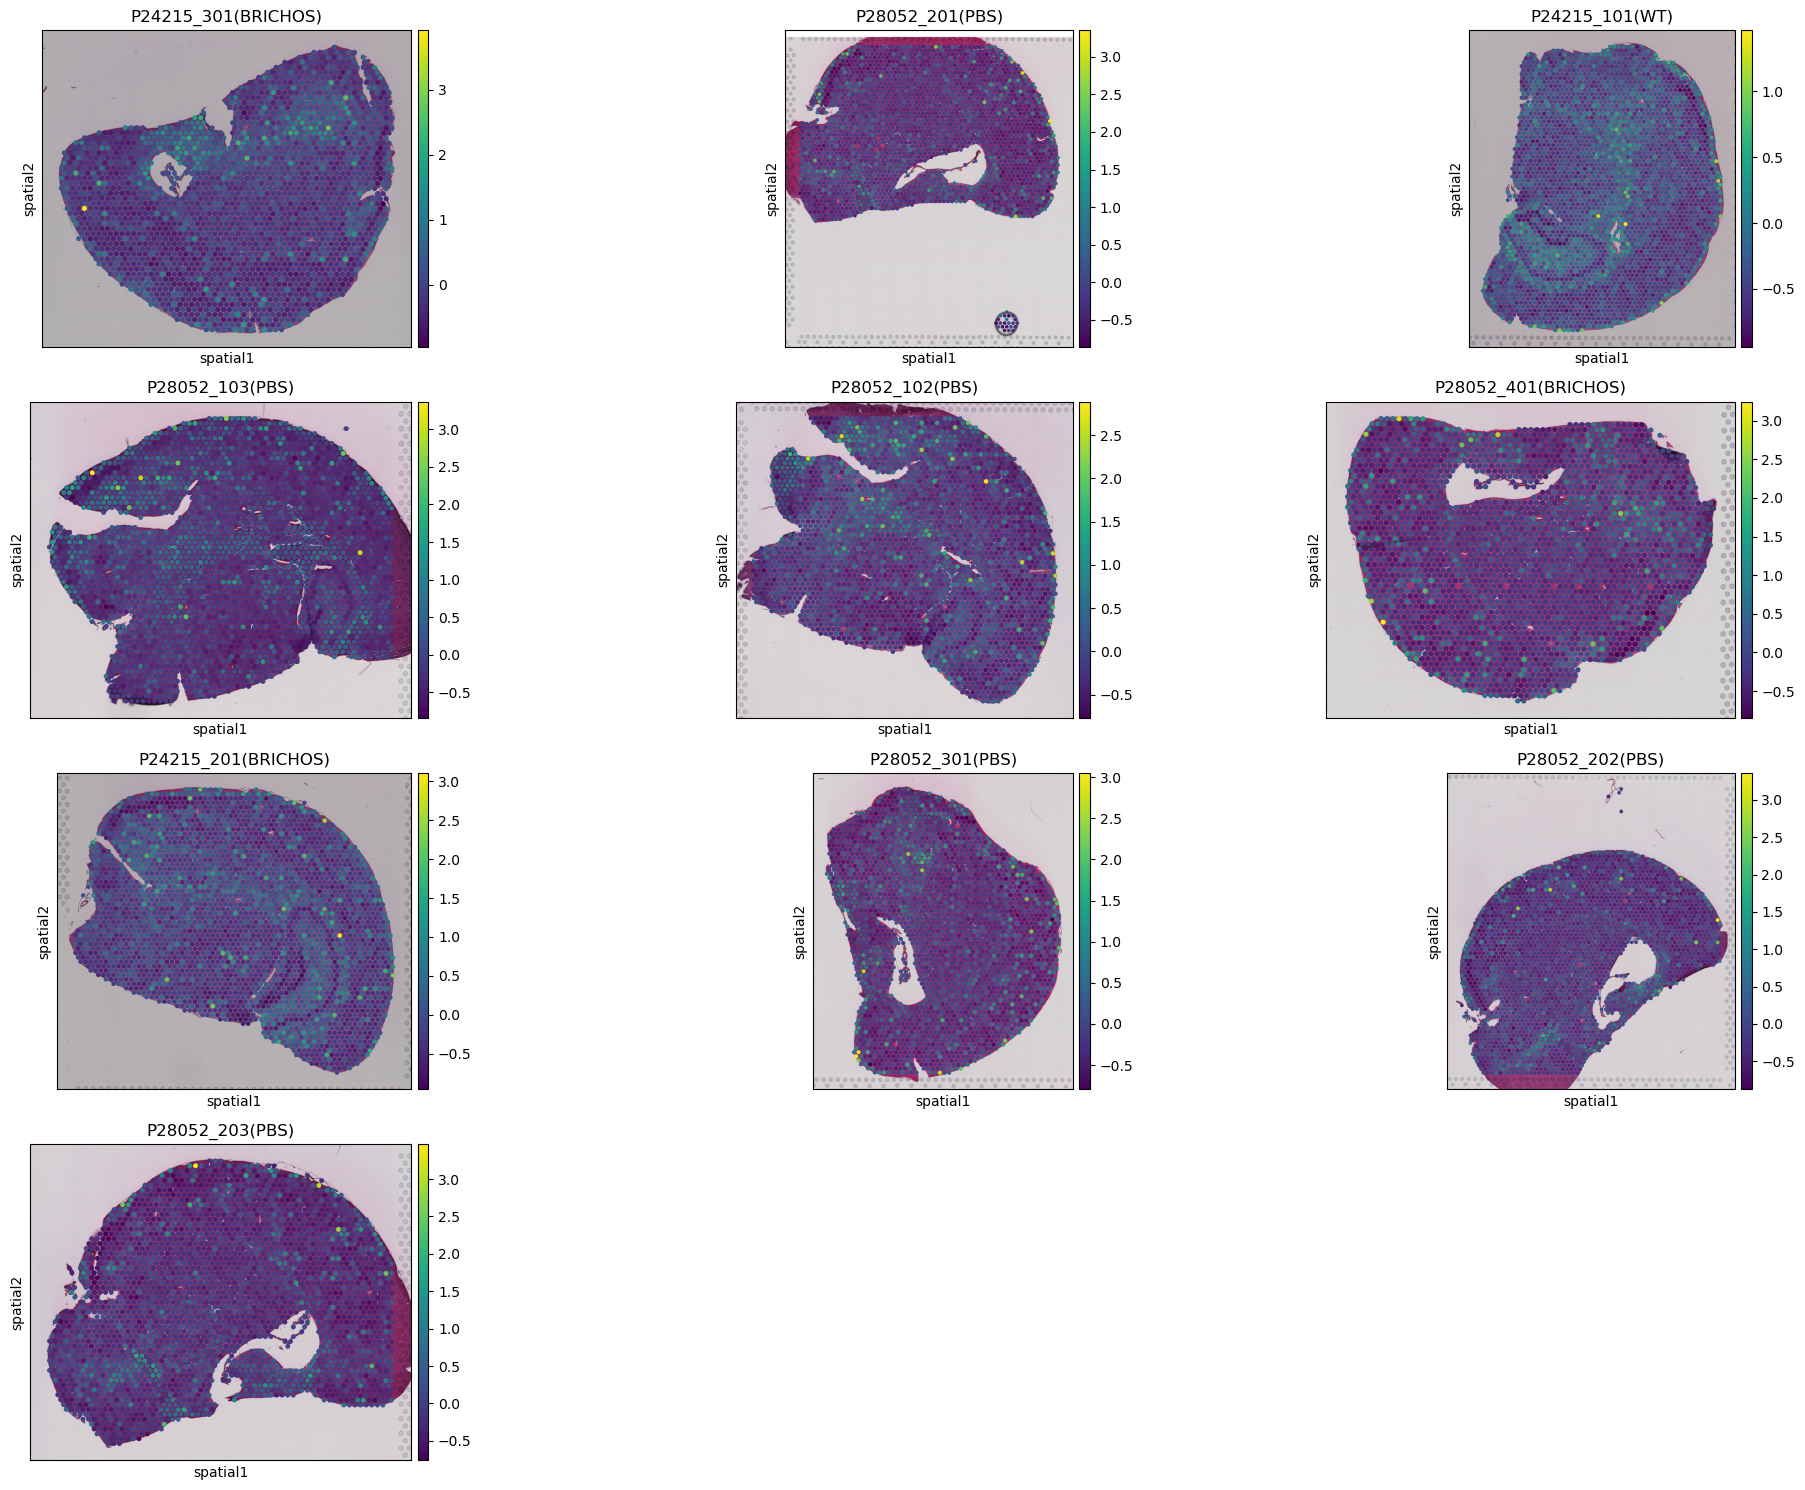

In [23]:
plot_spatial_clusters_per_sample(ad, color = 'PIG_score', figsize=(20,15))

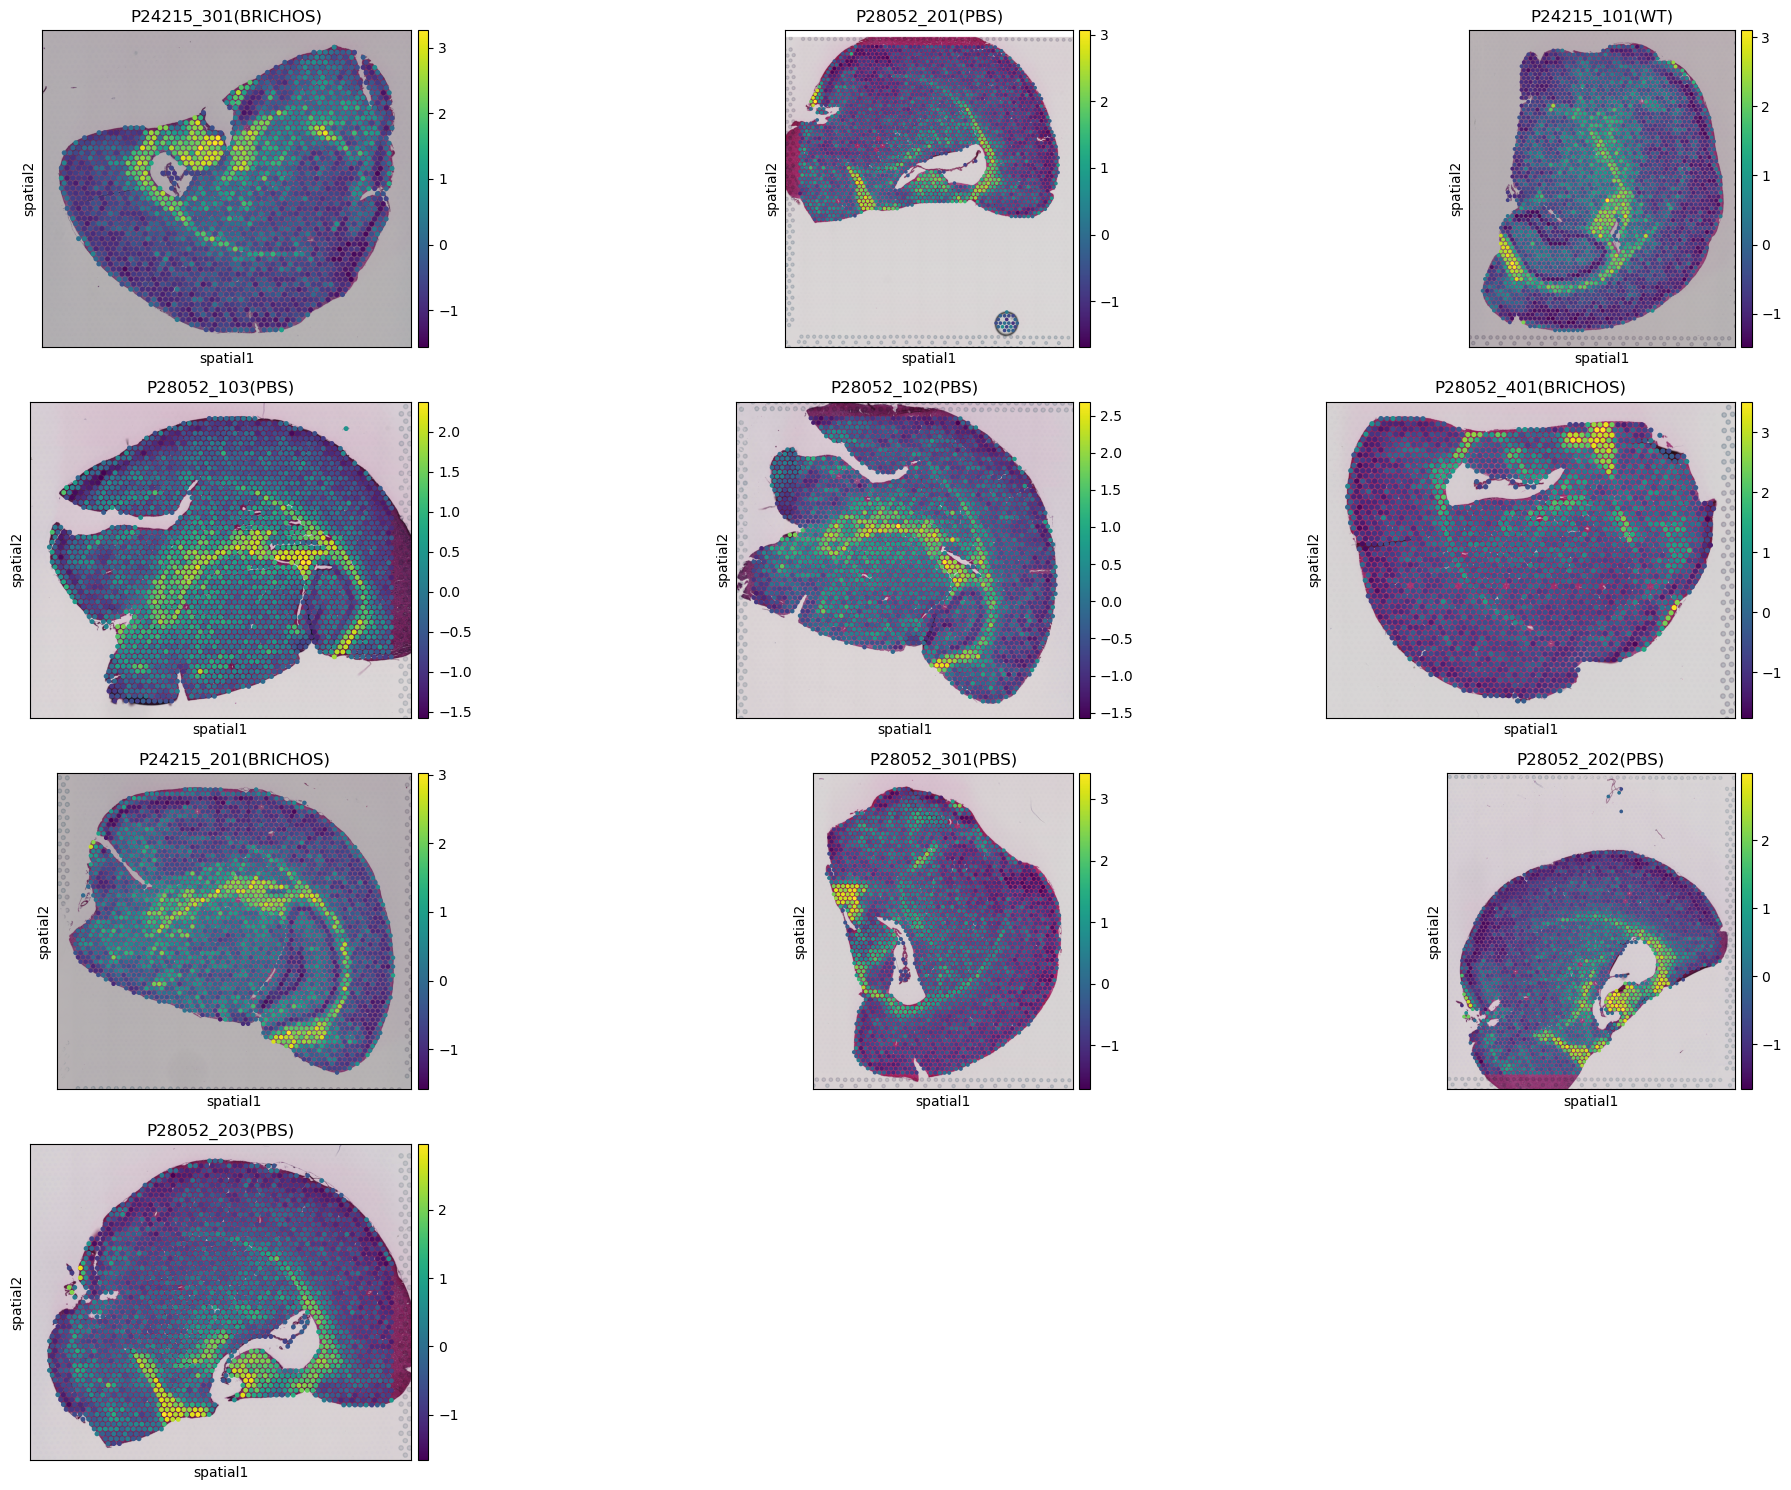

In [24]:
plot_spatial_clusters_per_sample(ad, color = 'OLIG_score', figsize=(20,15))

In [55]:
import pandas as pd

men = ad[ad.obs["re_annotation_regions"] == "Meninges"].copy()

# get raw counts
X = men.layers["counts"] if "counts" in men.layers else men.X
df = pd.DataFrame(X, index=men.obs_names, columns=men.var_names)
df["sample"] = men.obs["sample_id"]
df["treatment"] = men.obs["treatment"]

# pseudobulk: sum across spots for each sample
pb = df.groupby(["sample","treatment"]).sum()

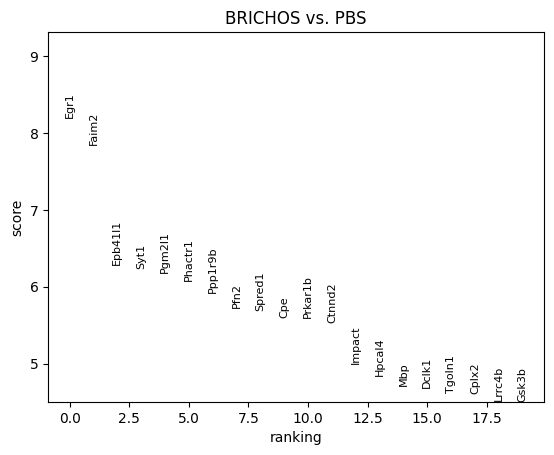

In [61]:
# Differential expression: BRICHOS vs PBS
sc.tl.rank_genes_groups(
    men,
    groupby="treatment",
    groups=["BRICHOS"],
    reference="PBS",
    method="wilcoxon"
)
# View top genes
sc.get.rank_genes_groups_df(men, group="BRICHOS").head(20)

# Plot top markers
sc.pl.rank_genes_groups(men, n_genes=20, sharey=False)

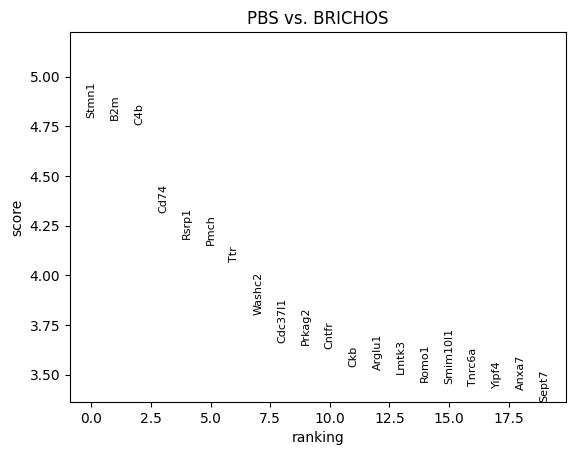

In [63]:
# Differential expression: BRICHOS vs PBS
sc.tl.rank_genes_groups(
    men,
    groupby="treatment",
    groups=["PBS"],
    reference="BRICHOS",
    method="wilcoxon"
)
# View top genes
sc.get.rank_genes_groups_df(men, group="PBS").head(20)

# Plot top markers
sc.pl.rank_genes_groups(men, n_genes=20, sharey=False)

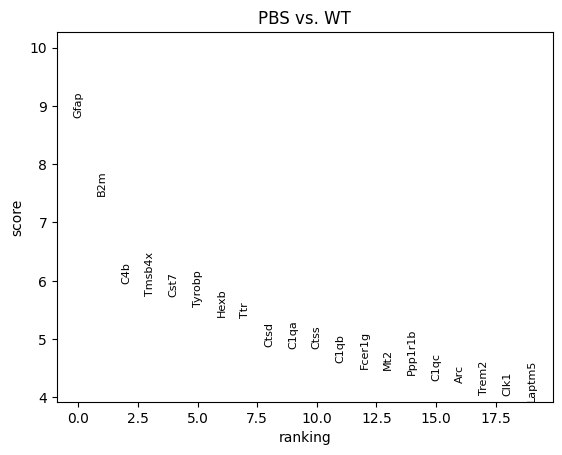

In [65]:
# Differential expression: BRICHOS vs PBS
sc.tl.rank_genes_groups(
    men,
    groupby="treatment",
    groups=["PBS"],
    reference="WT",
    method="wilcoxon"
)
# View top genes
sc.get.rank_genes_groups_df(men, group="PBS").head(20)

# Plot top markers
sc.pl.rank_genes_groups(men, n_genes=20, sharey=False)

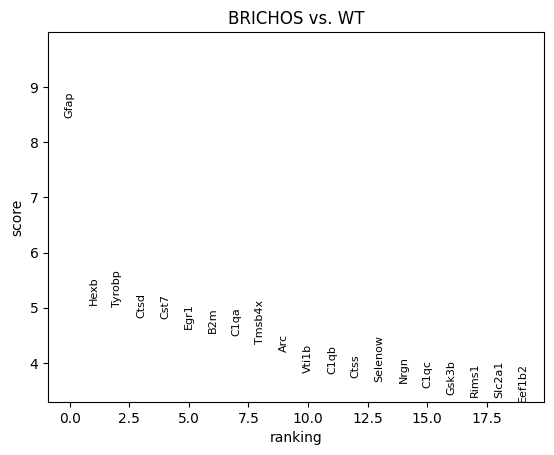

In [66]:
# Differential expression: BRICHOS vs PBS
sc.tl.rank_genes_groups(
    men,
    groupby="treatment",
    groups=["BRICHOS"],
    reference="WT",
    method="wilcoxon"
)
# View top genes
sc.get.rank_genes_groups_df(men, group="BRICHOS").head(20)

# Plot top markers
sc.pl.rank_genes_groups(men, n_genes=20, sharey=False)

In [73]:
markers = [
    "Gfap",
    "B2m",
    "Cab",
    "Tmsb4x",
    "Cst7",
    "Tyrobp",
    "Hexb",
    "Ttr",
    "Cst3",
    "C1qa",
    "C1qb",
    "C1qc",
    "Fcer1g",
    "Ppp1r1b",
    "Arc",
    "Trem2",
    "Cxcl1",
    "Laptm5"
]

In [74]:

# Collect results for each contrast
contrasts = [("PBS","WT"), ("BRICHOS","WT")]
results = []

for group, ref in contrasts:
    sc.tl.rank_genes_groups(
        ad,
        groupby="treatment",
        groups=[group],
        reference=ref,
        method="t-test",   # or "t-test"
        use_raw=False
    )
    df = sc.get.rank_genes_groups_df(ad, group=group)
    df["contrast"] = f"{group}_vs_{ref}"
    results.append(df)

de_all = pd.concat(results)

# Filter for your markers
de_subset = de_all[de_all["names"].isin(markers)][
    ["contrast","names","logfoldchanges","pvals_adj"]
]

print(de_subset)

            contrast    names  logfoldchanges      pvals_adj
0          PBS_vs_WT     Cst7        6.735904   0.000000e+00
1          PBS_vs_WT     Gfap        1.930943   0.000000e+00
4          PBS_vs_WT   Tyrobp        1.843857   0.000000e+00
6          PBS_vs_WT      B2m        0.963690  1.509649e-300
7          PBS_vs_WT     C1qa        1.041871  6.268013e-244
8          PBS_vs_WT      Arc        1.100154  5.096667e-242
9          PBS_vs_WT     C1qc        1.137827  5.086630e-239
15         PBS_vs_WT    Trem2        1.658580  1.971166e-225
18         PBS_vs_WT     Hexb        0.893799  5.845765e-209
21         PBS_vs_WT     C1qb        1.073623  1.173949e-183
28         PBS_vs_WT   Laptm5        1.132154  8.284833e-144
31         PBS_vs_WT   Fcer1g        1.219759  7.456382e-139
41         PBS_vs_WT  Ppp1r1b        0.804950  1.048589e-111
51         PBS_vs_WT     Cst3        0.288518   1.551289e-94
238        PBS_vs_WT      Ttr        0.413508   3.547380e-41
240        PBS_vs_WT   T

In [75]:

# Filter for your markers
de_subset = de_all[de_all["names"].isin(pig_genes)][
    ["contrast","names","logfoldchanges","pvals_adj"]
]

print(de_subset)

           contrast      names  logfoldchanges      pvals_adj
0         PBS_vs_WT       Cst7        6.735904   0.000000e+00
4         PBS_vs_WT     Tyrobp        1.843857   0.000000e+00
7         PBS_vs_WT       C1qa        1.041871  6.268013e-244
9         PBS_vs_WT       C1qc        1.137827  5.086630e-239
15        PBS_vs_WT      Trem2        1.658580  1.971166e-225
16        PBS_vs_WT        C4b        1.373837  6.570907e-217
18        PBS_vs_WT       Hexb        0.893799  5.845765e-209
21        PBS_vs_WT       C1qb        1.073623  1.173949e-183
23        PBS_vs_WT       Ctsd        0.735183  7.531335e-165
31        PBS_vs_WT     Fcer1g        1.219759  7.456382e-139
42        PBS_vs_WT      Itgax        5.346600  6.102858e-115
51        PBS_vs_WT       Cst3        0.288518   1.551289e-94
72        PBS_vs_WT        Lpl        0.965468   9.978153e-79
77        PBS_vs_WT       Ctsb        0.229893   1.657901e-74
181       PBS_vs_WT      Gpnmb        1.406748   5.118887e-48
242     

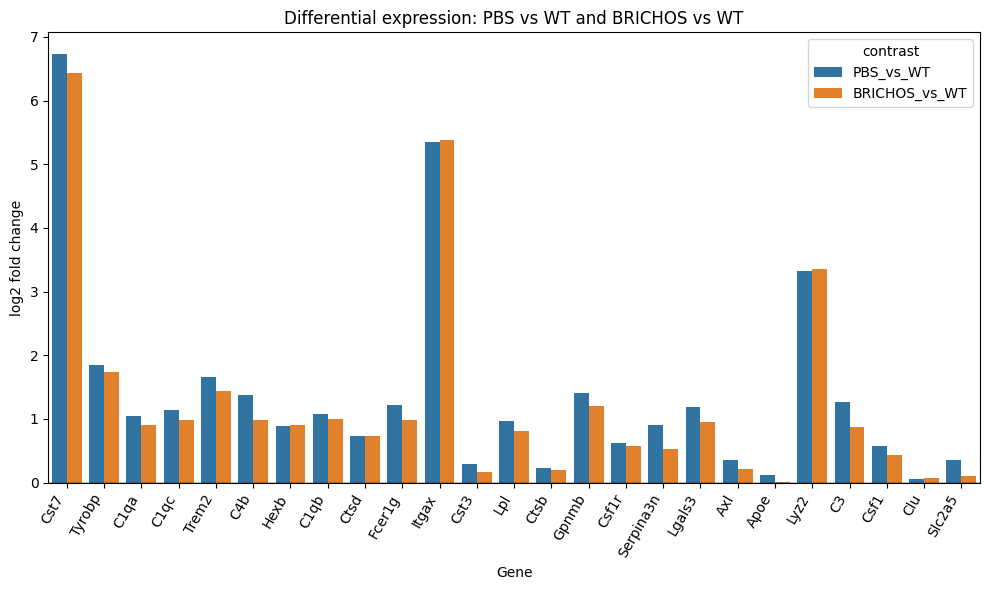

In [78]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Put your DE results into a dataframe (example: df = pd.DataFrame(...))
# Ensure it has columns: ["contrast","names","logfoldchanges","pvals_adj"]

# Keep only markers of interest (your list above already is)

# Plot
plt.figure(figsize=(10,6))
sns.barplot(
    data=de_subset[de_subset["names"].isin(pig_genes)],
    x="names", y="logfoldchanges", hue="contrast"
)

plt.axhline(0, color="black", linewidth=1)
plt.xticks(rotation=60, ha="right")
plt.ylabel("log2 fold change")
plt.xlabel("Gene")
plt.title("Differential expression: PBS vs WT and BRICHOS vs WT")
plt.tight_layout()
plt.show()